Importing Packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

Uploading files

In [4]:
leases=pd.read_csv('Data in CSV/leases.csv')
properties=pd.read_csv('Data in CSV/properties.csv',delimiter=';')
locations=pd.read_csv('Data in CSV/locations.csv',delimiter=';')
units=pd.read_csv('Data in CSV/units.csv',delimiter=';')
tenants=pd.read_csv('Data in CSV/tenants.csv',delimiter=';')

In [5]:
tables=[leases,properties,locations,units,tenants]

Checking missing values

In [6]:
for table in tables:
    data=table.isna().sum()
    missing=data[data>0]
    for col,count in missing.items():
        print(f" {col} : {count}")

 end_date : 5
 email : 1


Check for duplicates

In [28]:
for table in tables:
    duplicates=table.duplicated().sum()
    print(duplicates)

0
0
0
0
0


Changing rent and arrears to absolute values

In [7]:
leases['rent_per_month']=leases['rent_per_month'].abs()
leases['arrears']=leases['arrears'].abs()

Updating missing  end dates to todays date and Converting to appropriate date types

In [11]:
today=pd.Timestamp.today().normalize()
leases['end_date']=pd.to_datetime(leases['end_date'].fillna(today))

In [13]:
strip=lambda x:x.strip()
leases['start_date']=leases['start_date'].apply(strip)
leases['start_date']=pd.to_datetime(leases['start_date'],format="%d/%m/%Y")

In [14]:
leases.dtypes

id                         int64
unit_id                    int64
tenant_id                  int64
rent_per_month             int64
arrears                    int64
start_date        datetime64[ns]
end_date          datetime64[ns]
dtype: object

In [22]:
leases=leases.astype({
    'arrears':float,
    'rent_per_month':float
}).copy()

Calculated fields : lease duration in months,annual_rent,lease_status,valid_lease

In [29]:
months=(leases['end_date'].dt.year-leases['start_date'].dt.year)*12 + (leases['end_date'].dt.month-leases['start_date'].dt.month)
partials=leases['end_date'].dt.day>leases['start_date'].dt.day
leases['total_months']=months+partials.astype(int)
leases

,id,unit_id,tenant_id,rent_per_month,arrears,start_date,end_date,total_months
0,1,1,1,45000.0,0.0,2024-01-01,2025-11-21,23
1,2,2,2,55000.0,5000.0,2023-11-01,2024-10-31,12
2,3,3,3,65000.0,2000.0,2024-02-01,2025-11-21,22
3,4,4,4,30000.0,1000.0,2024-03-01,2025-11-21,21
4,5,5,3,70000.0,0.0,2025-02-01,2025-12-31,11
5,6,6,5,40000.0,8000.0,2024-06-15,2025-06-14,12
6,7,7,6,52000.0,0.0,2024-08-01,2024-07-31,0
7,8,8,7,38000.0,12000.0,2023-09-01,2025-11-21,27
8,9,9,8,60000.0,0.0,2025-01-01,2025-11-21,11
9,10,10,2,45000.0,1000.0,2024-02-01,2024-12-31,11


In [30]:
leases['annual_rent']=leases['rent_per_month']*12

In [ ]:
valid_lease (1 if start_date < end_date OR end_date is ) and 
start_date <= today; else 0). 

In [47]:
mapper=lambda x:1 if ((x['start_date'] < x['end_date']) | (pd.isna(x['end_date']))) & (x['start_date']<=today) else 0

In [48]:
leases['valid_lease']=leases.apply(mapper,axis=1)

In [39]:
leases['rent_paid']=leases['rent_per_month']*leases['total_months']

In [57]:
conditions = [
    (leases['start_date'] < leases['end_date']) & 
    (leases['start_date'] <= today) & 
    (leases['end_date'] >= today),

    (leases['start_date'] < leases['end_date']) &
    (leases['end_date'] <= today),

    (leases['start_date'] > leases['end_date']) | (leases['start_date'] > today)
]
choices=['ongoing','expired','invalid']
leases['lease_status']=np.select(conditions,choices,default='invalid')

Convert to Proper Case

In [62]:
locations['name']=locations['name'].str.strip().str.lower().str.title()

In [63]:
locations

,id,name
0,1,Nairobi Cbd
1,2,Westlands
2,3,Kilimani


In [ ]:
leases.to_csv("Data in CSV/CleanedLeases.csv")

In [66]:
leases.drop('st',axis=1,inplace=True)

PERFOMING JOINS WITH RELATED TABLES TO ALLOW WHOLESOME ANALYSIS

 lease with units

In [67]:
lease_units=pd.merge(leases,units,left_on='unit_id',right_on='id',suffixes=['','_units']).drop('id_units',axis=1) 
lease_units

,id,unit_id,tenant_id,rent_per_month,arrears,start_date,end_date,total_months,annual_rent,rent_paid,valid_lease,lease_status,property_id,name,size
0,1,1,1,45000.0,0.0,2024-01-01,2025-11-21,23,540000.0,1035000.0,1,ongoing,1,A-101,75.0
1,2,2,2,55000.0,5000.0,2023-11-01,2024-10-31,12,660000.0,660000.0,1,expired,1,A-102,80.5
2,3,3,3,65000.0,2000.0,2024-02-01,2025-11-21,22,780000.0,1430000.0,1,ongoing,1,B-201,65.0
3,4,4,4,30000.0,1000.0,2024-03-01,2025-11-21,21,360000.0,630000.0,1,ongoing,1,B-202,92.0
4,5,5,3,70000.0,0.0,2025-02-01,2025-12-31,11,840000.0,770000.0,1,ongoing,1,C-301,120.0
5,6,6,5,40000.0,8000.0,2024-06-15,2025-06-14,12,480000.0,480000.0,1,expired,2,DC-1A,55.0
6,7,7,6,52000.0,0.0,2024-08-01,2024-07-31,0,624000.0,0.0,0,invalid,2,DC-1B,60.0
7,8,8,7,38000.0,12000.0,2023-09-01,2025-11-21,27,456000.0,1026000.0,1,ongoing,2,DC-2A,85.0
8,9,9,8,60000.0,0.0,2025-01-01,2025-11-21,11,720000.0,660000.0,1,ongoing,2,DC-2B,100.0
9,10,10,2,45000.0,1000.0,2024-02-01,2024-12-31,11,540000.0,495000.0,1,expired,2,DC-3A,73.5


 lease with units with properties

In [96]:
lease_units_property=pd.merge(lease_units,properties,left_on='property_id',right_on='id',suffixes=['','_property']).drop('property_id',axis=1)
lease_units_property

,id,unit_id,tenant_id,rent_per_month,arrears,start_date,end_date,total_months,annual_rent,rent_paid,valid_lease,lease_status,name,size,id_property,name_property,location_id
0,1,1,1,45000.0,0.0,2024-01-01,2025-11-21,23,540000.0,1035000.0,1,ongoing,A-101,75.0,1,NSSF Towers,1
1,2,2,2,55000.0,5000.0,2023-11-01,2024-10-31,12,660000.0,660000.0,1,expired,A-102,80.5,1,NSSF Towers,1
2,3,3,3,65000.0,2000.0,2024-02-01,2025-11-21,22,780000.0,1430000.0,1,ongoing,B-201,65.0,1,NSSF Towers,1
3,4,4,4,30000.0,1000.0,2024-03-01,2025-11-21,21,360000.0,630000.0,1,ongoing,B-202,92.0,1,NSSF Towers,1
4,5,5,3,70000.0,0.0,2025-02-01,2025-12-31,11,840000.0,770000.0,1,ongoing,C-301,120.0,1,NSSF Towers,1
5,6,6,5,40000.0,8000.0,2024-06-15,2025-06-14,12,480000.0,480000.0,1,expired,DC-1A,55.0,2,Delta Corner,2
6,7,7,6,52000.0,0.0,2024-08-01,2024-07-31,0,624000.0,0.0,0,invalid,DC-1B,60.0,2,Delta Corner,2
7,8,8,7,38000.0,12000.0,2023-09-01,2025-11-21,27,456000.0,1026000.0,1,ongoing,DC-2A,85.0,2,Delta Corner,2
8,9,9,8,60000.0,0.0,2025-01-01,2025-11-21,11,720000.0,660000.0,1,ongoing,DC-2B,100.0,2,Delta Corner,2
9,10,10,2,45000.0,1000.0,2024-02-01,2024-12-31,11,540000.0,495000.0,1,expired,DC-3A,73.5,2,Delta Corner,2


 lease with units with properties with location

In [71]:
lease_location=pd.merge(lease_units_property,locations,left_on='location_id',right_on='id').drop(['id_x','id_y','location_id','id_property'],axis=1)
lease_location

,unit_id,tenant_id,rent_per_month,arrears,start_date,end_date,total_months,annual_rent,rent_paid,valid_lease,lease_status,name_x,size,name_property,name_y
0,1,1,45000.0,0.0,2024-01-01,2025-11-21,23,540000.0,1035000.0,1,ongoing,A-101,75.0,NSSF Towers,Nairobi Cbd
1,2,2,55000.0,5000.0,2023-11-01,2024-10-31,12,660000.0,660000.0,1,expired,A-102,80.5,NSSF Towers,Nairobi Cbd
2,3,3,65000.0,2000.0,2024-02-01,2025-11-21,22,780000.0,1430000.0,1,ongoing,B-201,65.0,NSSF Towers,Nairobi Cbd
3,4,4,30000.0,1000.0,2024-03-01,2025-11-21,21,360000.0,630000.0,1,ongoing,B-202,92.0,NSSF Towers,Nairobi Cbd
4,5,3,70000.0,0.0,2025-02-01,2025-12-31,11,840000.0,770000.0,1,ongoing,C-301,120.0,NSSF Towers,Nairobi Cbd
5,6,5,40000.0,8000.0,2024-06-15,2025-06-14,12,480000.0,480000.0,1,expired,DC-1A,55.0,Delta Corner,Westlands
6,7,6,52000.0,0.0,2024-08-01,2024-07-31,0,624000.0,0.0,0,invalid,DC-1B,60.0,Delta Corner,Westlands
7,8,7,38000.0,12000.0,2023-09-01,2025-11-21,27,456000.0,1026000.0,1,ongoing,DC-2A,85.0,Delta Corner,Westlands
8,9,8,60000.0,0.0,2025-01-01,2025-11-21,11,720000.0,660000.0,1,ongoing,DC-2B,100.0,Delta Corner,Westlands
9,10,2,45000.0,1000.0,2024-02-01,2024-12-31,11,540000.0,495000.0,1,expired,DC-3A,73.5,Delta Corner,Westlands


In [72]:
lease_location.rename(columns={'name_y':'location','name_x':'unit_name','name_property':'property_name'},inplace=True)

In [73]:
lease_location

,unit_id,tenant_id,rent_per_month,arrears,start_date,end_date,total_months,annual_rent,rent_paid,valid_lease,lease_status,unit_name,size,property_name,location
0,1,1,45000.0,0.0,2024-01-01,2025-11-21,23,540000.0,1035000.0,1,ongoing,A-101,75.0,NSSF Towers,Nairobi Cbd
1,2,2,55000.0,5000.0,2023-11-01,2024-10-31,12,660000.0,660000.0,1,expired,A-102,80.5,NSSF Towers,Nairobi Cbd
2,3,3,65000.0,2000.0,2024-02-01,2025-11-21,22,780000.0,1430000.0,1,ongoing,B-201,65.0,NSSF Towers,Nairobi Cbd
3,4,4,30000.0,1000.0,2024-03-01,2025-11-21,21,360000.0,630000.0,1,ongoing,B-202,92.0,NSSF Towers,Nairobi Cbd
4,5,3,70000.0,0.0,2025-02-01,2025-12-31,11,840000.0,770000.0,1,ongoing,C-301,120.0,NSSF Towers,Nairobi Cbd
5,6,5,40000.0,8000.0,2024-06-15,2025-06-14,12,480000.0,480000.0,1,expired,DC-1A,55.0,Delta Corner,Westlands
6,7,6,52000.0,0.0,2024-08-01,2024-07-31,0,624000.0,0.0,0,invalid,DC-1B,60.0,Delta Corner,Westlands
7,8,7,38000.0,12000.0,2023-09-01,2025-11-21,27,456000.0,1026000.0,1,ongoing,DC-2A,85.0,Delta Corner,Westlands
8,9,8,60000.0,0.0,2025-01-01,2025-11-21,11,720000.0,660000.0,1,ongoing,DC-2B,100.0,Delta Corner,Westlands
9,10,2,45000.0,1000.0,2024-02-01,2024-12-31,11,540000.0,495000.0,1,expired,DC-3A,73.5,Delta Corner,Westlands


A:Total Rent Billed vs Total Arrears by Location. 

In [75]:
rent_arrears=lease_location[lease_location['valid_lease']==1].groupby('location')[['rent_per_month','arrears']].sum()
rent_arrears

,rent_per_month,arrears
location,,
Kilimani,78000.0,3000.0
Nairobi Cbd,265000.0,8000.0
Westlands,183000.0,21000.0


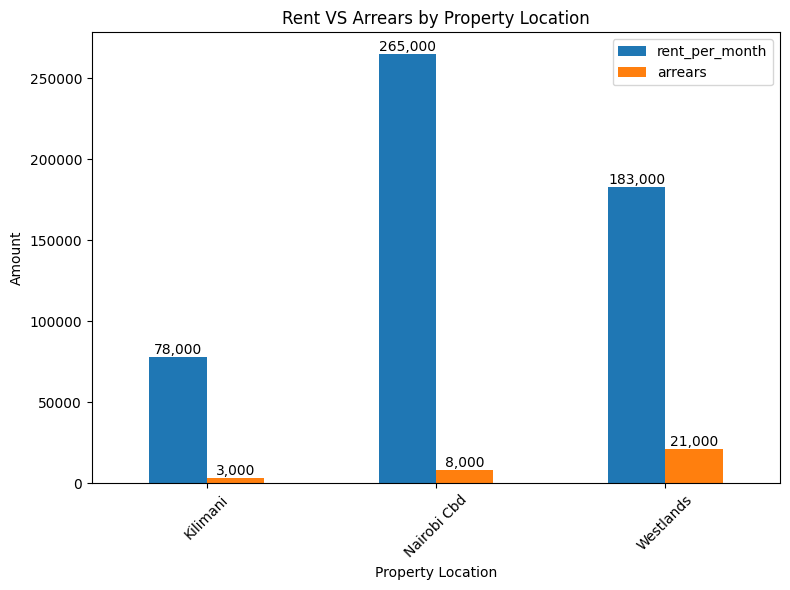

In [78]:
ax=rent_arrears.plot(kind='bar',figsize=(8,6))
plt.title("Rent VS Arrears by Property Location")
plt.xlabel("Property Location")
plt.ylabel("Amount")
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}'.format)
plt.tight_layout()
plt.show()

B:Occupancy Rate per Property. 

perform right join on units to get all units and properties even those without leases

In [80]:
lease_units_all=pd.merge(leases,units,left_on='unit_id',right_on='id',how='right',suffixes=['_leases','_units']).drop('id_units',axis=1) 


In [82]:
lease_units_property_all=pd.merge(lease_units_all,properties,left_on='property_id',right_on='id',suffixes=['_unit','_property']).drop(['property_id','id','location_id'],axis=1)


In [83]:
lease_units_property_all.rename(columns={'name_unit':'unit_name','name_property':'property_name'},inplace=True)

In [84]:
lease_units_property_all

,id_leases,unit_id,tenant_id,rent_per_month,arrears,start_date,end_date,total_months,annual_rent,rent_paid,valid_lease,lease_status,unit_name,size,property_name
0,1.0,1.0,1.0,45000.0,0.0,2024-01-01,2025-11-21,23.0,540000.0,1035000.0,1.0,ongoing,A-101,75.0,NSSF Towers
1,2.0,2.0,2.0,55000.0,5000.0,2023-11-01,2024-10-31,12.0,660000.0,660000.0,1.0,expired,A-102,80.5,NSSF Towers
2,3.0,3.0,3.0,65000.0,2000.0,2024-02-01,2025-11-21,22.0,780000.0,1430000.0,1.0,ongoing,B-201,65.0,NSSF Towers
3,4.0,4.0,4.0,30000.0,1000.0,2024-03-01,2025-11-21,21.0,360000.0,630000.0,1.0,ongoing,B-202,92.0,NSSF Towers
4,5.0,5.0,3.0,70000.0,0.0,2025-02-01,2025-12-31,11.0,840000.0,770000.0,1.0,ongoing,C-301,120.0,NSSF Towers
5,6.0,6.0,5.0,40000.0,8000.0,2024-06-15,2025-06-14,12.0,480000.0,480000.0,1.0,expired,DC-1A,55.0,Delta Corner
6,7.0,7.0,6.0,52000.0,0.0,2024-08-01,2024-07-31,0.0,624000.0,0.0,0.0,invalid,DC-1B,60.0,Delta Corner
7,8.0,8.0,7.0,38000.0,12000.0,2023-09-01,2025-11-21,27.0,456000.0,1026000.0,1.0,ongoing,DC-2A,85.0,Delta Corner
8,9.0,9.0,8.0,60000.0,0.0,2025-01-01,2025-11-21,11.0,720000.0,660000.0,1.0,ongoing,DC-2B,100.0,Delta Corner
9,10.0,10.0,2.0,45000.0,1000.0,2024-02-01,2024-12-31,11.0,540000.0,495000.0,1.0,expired,DC-3A,73.5,Delta Corner


In [85]:
property_unit_leases=lease_units_property_all.groupby('property_name')[['unit_name','id_leases']].count()
property_unit_leases

,unit_name,id_leases
property_name,,
Delta Corner,5,5
Kimathi House,3,0
NSSF Towers,5,5
Riverside Court,3,0
The Junction Residences,4,2


In [86]:
property_unit_leases.rename(columns={'unit_name':'total_no_units','id_leases':'units_with_leases'},inplace=True)
property_unit_leases['%with_leases']=property_unit_leases['units_with_leases']/property_unit_leases['total_no_units']*100

In [87]:
property_unit_leases

,total_no_units,units_with_leases,%with_leases
property_name,,,
Delta Corner,5,5,100.0
Kimathi House,3,0,0.0
NSSF Towers,5,5,100.0
Riverside Court,3,0,0.0
The Junction Residences,4,2,50.0


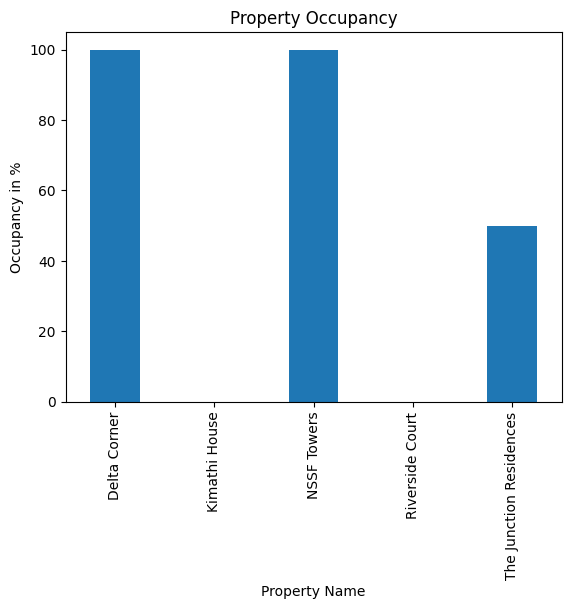

In [88]:
property_unit_leases['%with_leases'].plot(kind='bar')
plt.title("Property Occupancy")
plt.xlabel("Property Name")
plt.ylabel("Occupancy in %")
plt.show()  

C:op 3 Properties by Arrears. 

In [90]:
property_arrears=lease_units_property.groupby('name_property')['arrears'].sum().reset_index()
property_arrears

,name_property,arrears
0,Delta Corner,21000.0
1,NSSF Towers,8000.0
2,The Junction Residences,3000.0


D:Average Monthly Rent per Property and per Location.

In [99]:
lease_units_property_location=pd.merge(lease_units_property,locations,left_on='location_id',right_on='id')


In [103]:
lease_units_property_location.rename(columns={'name_y':'location'},inplace=True)

In [104]:
avg_rent=lease_units_property_location.groupby(['name_property','location'])['rent_per_month'].mean().reset_index().rename(columns={'rent_per_month':'Average_monthly_rent'})

In [105]:
avg_rent.sort_values(by='Average_monthly_rent',ascending=False)

,name_property,location,Average_monthly_rent
1,NSSF Towers,Nairobi Cbd,53000.0
0,Delta Corner,Westlands,47000.0
2,The Junction Residences,Kilimani,39000.0


PERSONAL POSSIBLE ANALYSIS

1:SIZE to RENT comparison in different locations

In [107]:
size_rent=lease_units_property_location.groupby('location')[['size','rent_per_month']].mean().reset_index()
size_rent.sort_values(by='size',ascending=False,inplace=True)
size_rent

,location,size,rent_per_month
1,Nairobi Cbd,86.5,53000.0
2,Westlands,74.7,47000.0
0,Kilimani,50.0,39000.0


2:Highest rent paying tenats

In [112]:
user_leases=pd.merge(lease_units_property_location,tenants,left_on='tenant_id',right_on='id').drop(['id'],axis=1)

In [109]:
user_rents=user_leases.groupby('name')['rent_paid'].sum().sort_values(ascending=False).reset_index()
user_rents

,name,rent_paid
0,Carol Wanjiru,2200000.0
1,Brian Otieno,1155000.0
2,Amina Mwangi,1035000.0
3,George Ouma,1026000.0
4,Hannah Achieng,660000.0
5,David Kiptoo,630000.0
6,Joy Wambui,564000.0
7,Eunice Njeri,480000.0
8,Ian Wachira,372000.0
9,Farah Hassan,0.0


factoring in no of units they own

In [114]:
user_rents=user_leases.groupby('name').agg(rent_paid=('rent_paid','mean'),no_units=('tenant_id','count')).reset_index()
user_rents.sort_values(by='rent_paid',ascending=False,inplace=True)
user_rents

,name,rent_paid,no_units
2,Carol Wanjiru,1100000.0,2
0,Amina Mwangi,1035000.0,1
6,George Ouma,1026000.0,1
7,Hannah Achieng,660000.0,1
3,David Kiptoo,630000.0,1
1,Brian Otieno,577500.0,2
9,Joy Wambui,564000.0,1
4,Eunice Njeri,480000.0,1
8,Ian Wachira,372000.0,1
5,Farah Hassan,0.0,1


3:Tenants with the highest Arrears

In [118]:
user_arrears=user_leases.groupby('name')['arrears'].sum().sort_values(ascending=False).reset_index()
user_arrears

,name,arrears
0,George Ouma,12000.0
1,Eunice Njeri,8000.0
2,Brian Otieno,6000.0
3,Joy Wambui,3000.0
4,Carol Wanjiru,2000.0
5,David Kiptoo,1000.0
6,Amina Mwangi,0.0
7,Farah Hassan,0.0
8,Hannah Achieng,0.0
9,Ian Wachira,0.0
